In [2]:
# Cell 1 — Imports (fix Path error here)
import sys
import importlib.util
from pathlib import Path

import numpy as np
import torch

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from random import random

In [3]:
# Cell 2 — Point to your training script + dynamic import as module
# CHANGE THIS to the real path of your training script file:
TRAIN_SCRIPT_PATH = Path("./train_cluster_reconstruction.py")  # <-- rename as needed

assert TRAIN_SCRIPT_PATH.exists(), f"Training script not found: {TRAIN_SCRIPT_PATH.resolve()}"

spec = importlib.util.spec_from_file_location("cluster_recon_train", str(TRAIN_SCRIPT_PATH))
trainmod = importlib.util.module_from_spec(spec)
sys.modules["cluster_recon_train"] = trainmod
spec.loader.exec_module(trainmod)

print("Imported module:", trainmod)
print("Has MaskedClusterModel:", hasattr(trainmod, "MaskedClusterModel"))
print("Has compute_typicality_scores:", hasattr(trainmod, "compute_typicality_scores"))
print("Has extract_semantic_embeddings:", hasattr(trainmod, "extract_semantic_embeddings"))

Imported module: <module 'cluster_recon_train' from '/projets/Fbassignana/diffusers_try/flow_matching_trial/train_cluster_reconstruction.py'>
Has MaskedClusterModel: True
Has compute_typicality_scores: True
Has extract_semantic_embeddings: True


In [3]:
# Cell 3 — Config (edit these)
DATA_ROOT = Path("./v18")
SPLIT = "train"
DINO_NAME = "dinov2_vits14"
K_REGIONS = 5

RUN_DIR = Path("./runs/cluster_reconstruction/emb32_hidden256_proj_mask50_k5")  # folder that contains best_model.pt
CKPT_PATH = RUN_DIR / "best_model.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_N_SAMPLES = 2000

BATCH_SIZE_EMB = 256
BATCH_SIZE_TYP = 64
TYPICALITY_CHUNK = 32
TYPICALITY_MAX_BATCHES = 0  # 0 = no limit

print("DEVICE:", DEVICE)
print("CKPT:", CKPT_PATH, "exists:", CKPT_PATH.exists())

DEVICE: cuda
CKPT: runs/cluster_reconstruction/emb32_hidden256_proj_mask50_k5/best_model.pt exists: True


In [4]:
# Cell 4 — Load checkpoint + instantiate the EXACT model class from training script
assert CKPT_PATH.exists(), f"Missing checkpoint: {CKPT_PATH}"
ckpt = torch.load(CKPT_PATH, map_location="cpu")

emb_dim = int(ckpt.get("emb_dim"))
hidden_dim = int(ckpt.get("hidden_dim"))
k_regions_ckpt = int(ckpt.get("k_regions"))
mask_id = int(ckpt.get("mask_id"))

print("ckpt epoch:", ckpt.get("epoch"))
print("k_regions:", k_regions_ckpt, "emb_dim:", emb_dim, "hidden_dim:", hidden_dim, "mask_id:", mask_id)

model = trainmod.MaskedClusterModel(
    k_regions=k_regions_ckpt,
    emb_dim=emb_dim,
    hidden=hidden_dim
).to(DEVICE)

model.load_state_dict(ckpt["model_state"])
model.eval()

# sanity
dummy = torch.zeros(2, 16, 16, dtype=torch.long, device=DEVICE)
out = model(dummy)
print("Sanity logits:", tuple(out.shape))

ckpt epoch: 138
k_regions: 5 emb_dim: 32 hidden_dim: 256 mask_id: 5
Sanity logits: (2, 5, 16, 16)


In [5]:
# Cell 5 — Build dataset stems using functions from the training module
IMG_DIR = DATA_ROOT / SPLIT
ANN_PATH = IMG_DIR / "annotations.json"
CLUSTER_MAPS_DIR = DATA_ROOT / "dino_global_clusters" / f"maps_{DINO_NAME}_k{K_REGIONS}"

assert CLUSTER_MAPS_DIR.exists(), f"Missing cluster maps: {CLUSTER_MAPS_DIR}"

stems_all = trainmod.build_stems(IMG_DIR, ANN_PATH, CLUSTER_MAPS_DIR)
print("Total stems:", len(stems_all))

if MAX_N_SAMPLES and MAX_N_SAMPLES < len(stems_all):
    rng = np.random.default_rng(0)
    stems = list(rng.choice(stems_all, size=MAX_N_SAMPLES, replace=False))
else:
    stems = stems_all

ds = trainmod.ClusterReconDataset(
    img_dir=IMG_DIR,
    cluster_maps_dir=CLUSTER_MAPS_DIR,
    stems=stems,
    k_regions=K_REGIONS
)

print("Dataset size used:", len(ds))
ex = ds[0]
print("Example stem:", ex["stem"], "lbl shape:", tuple(ex["cluster_lbl"].shape), "min/max:", ex["cluster_lbl"].min().item(), ex["cluster_lbl"].max().item())

Total stems: 6725
Dataset size used: 2000
Example stem: sequence-20250304-150004-148030-985d31-33109e0d789458993a3eb7ffddfcf3af0976998a62f85836886d6bc9801edf5b-16 lbl shape: (16, 16) min/max: 0 4


In [6]:
# Cell 6 — DataLoaders (reuse collate from training script)
from torch.utils.data import DataLoader

loader_emb = DataLoader(
    ds,
    batch_size=BATCH_SIZE_EMB,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=trainmod.collate,
)

loader_typ = DataLoader(
    ds,
    batch_size=BATCH_SIZE_TYP,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=trainmod.collate,
)

In [7]:
# Cell 7 — Extract semantic embeddings (reuse EXACT function from training script)
emb, stems_out = trainmod.extract_semantic_embeddings(loader_emb, model, DEVICE)
print("emb:", emb.shape, "stems:", len(stems_out))

emb: (2000, 256) stems: 2000


In [8]:
# Cell 8 — Compute typicality scores (reuse EXACT function from training script)
typ_surprise, stems_typ = trainmod.compute_typicality_scores(
    loader=loader_typ,
    model=model,
    device=DEVICE,
    mask_id=mask_id,
    typicality_chunk=TYPICALITY_CHUNK,
    max_batches=TYPICALITY_MAX_BATCHES,
)

print("typ_surprise:", typ_surprise.shape, "stems:", len(stems_typ))

# order sanity: stems should match (both loaders shuffle=False over same ds)
assert stems_out == stems_typ, "Stem order mismatch between embeddings and typicality loaders."

Computing typicality scores: 100%|██████████| 32/32 [00:52<00:00,  1.64s/it]

typ_surprise: (2000,) stems: 2000


In [9]:
# Cell 9 — Convert surprise -> typicality score for coloring
# Surprise = mean(-log p) (lower => more typical)
# Typicality score = -surprise (higher => more typical)
typicality = -typ_surprise

t = typicality
t_norm = (t - t.min()) / (t.max() - t.min() + 1e-12)

print("typicality stats: min", float(t.min()), "max", float(t.max()), "mean", float(np.mean(t)), "std", float(np.std(t)))

typicality stats: min -0.8049538731575012 max -0.14910393953323364 mean -0.4829394519329071 std 0.11553064733743668


PCA explained variance: [0.30800763 0.21651559]


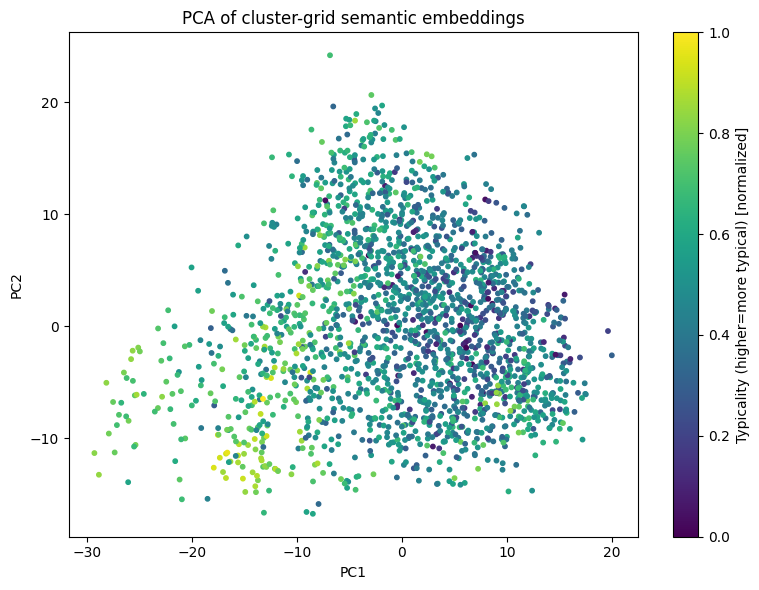

In [10]:
# Cell 10 — PCA plot colored by typicality
X = emb
Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0)
Xp = pca.fit_transform(Xz)

print("PCA explained variance:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
sc = plt.scatter(Xp[:, 0], Xp[:, 1], c=t_norm, s=10)
plt.colorbar(sc, label="Typicality (higher=more typical) [normalized]")
plt.title("PCA of cluster-grid semantic embeddings")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

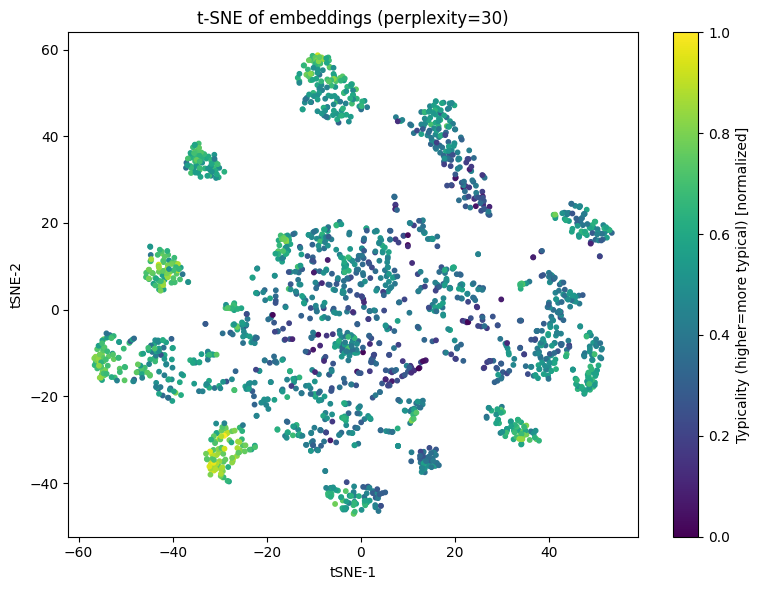

In [11]:
# Cell 11 — t-SNE plot colored by typicality
# NOTE: can be slow. Reduce MAX_N_SAMPLES if needed.
perplexity = min(30, max(5, len(Xz) // 50))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=0,
)

Xt = tsne.fit_transform(Xz)

plt.figure(figsize=(8, 6))
sc = plt.scatter(Xt[:, 0], Xt[:, 1], c=t_norm, s=10)
plt.colorbar(sc, label="Typicality (higher=more typical) [normalized]")
plt.title(f"t-SNE of embeddings (perplexity={perplexity})")
plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
plt.tight_layout()
plt.show()

# Mixture of gaussian fitting

In [16]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=15,
    covariance_type="full",
    random_state=0
)
gmm.fit(emb)

log_density = gmm.score_samples(emb)  # shape (N,)

In [17]:
import scipy.stats as stats

corr, p = stats.spearmanr(log_density, typicality)
print("Spearman correlation:", corr)

Spearman correlation: 0.4958694768971245


# Surprise/GMM Predictor — Post-training Evaluation Notebook

This notebook:
1) Loads a trained checkpoint produced by `train_surprise_predictor.py`
2) Rebuilds the model and dataset splits
3) Runs inference on val/test
4) Computes correlation metrics (Spearman/Pearson), error metrics (MSE/MAE)
5) Visualizes scatter, residuals, calibration-by-bins, ranking reliability
6) Shows qualitative examples (decoded images) for highest/lowest predicted scores

Main question:
**Is this predictor reliable enough to be integrated into Flow Matching training as a guidance/conditioning signal?**

In [4]:
import os
import json
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# --- adjust if needed ---
REPO_ROOT = Path(".").resolve()  # if notebook is in repo root, keep this
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from train_surprise_predictor import (
    SurprisePredictor,
    SurprisePredDataset,
    split_stems,
    spearman_corr,
    pearson_corr,
)

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [6]:
# ====== USER EDIT THESE ======
DS_ROOT = Path("surprise_pred_dataset").resolve()
VAE_MODEL_NAME = "vae_x4_best"  # folder inside DS_ROOT
CKPT_PATH = Path("runs/surprise_predictor_longrun/vae_x4_best_minmax_h256_s0/best_model.pt").resolve()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Target mode used in training: "minmax" or "raw"
# If you trained with "raw" (z-scored inside dataset), keep it "raw".
TARGET_MODE = "minmax"

# Data split fractions (must match training if you want identical splits)
SEED = 0
VAL_FRAC = 0.15
TEST_FRAC = 0.10

print("DS_ROOT:", DS_ROOT)
print("VAE_MODEL_NAME:", VAE_MODEL_NAME)
print("CKPT_PATH:", CKPT_PATH)
print("DEVICE:", DEVICE)
print("TARGET_MODE:", TARGET_MODE)

DS_ROOT: /projets/Fbassignana/diffusers_try/flow_matching_trial/surprise_pred_dataset
VAE_MODEL_NAME: vae_x4_best
CKPT_PATH: /projets/Fbassignana/diffusers_try/flow_matching_trial/runs/surprise_predictor_longrun/vae_x4_best_minmax_h256_s0/best_model.pt
DEVICE: cuda
TARGET_MODE: minmax


In [7]:
ckpt = torch.load(CKPT_PATH, map_location="cpu")
print("Checkpoint keys:", list(ckpt.keys()))

args = ckpt.get("args", {})
print("\nSaved args (subset):")
for k in ["ds_root","vae_model_name","vae_config","vae_weights","dino_name","hidden_dim","target_mode","seed","val_frac","test_frac"]:
    if k in args:
        print(f"  {k}: {args[k]}")

z_stats = ckpt.get("z_score_stats", None)
print("\nHas z_score_stats:", z_stats is not None)
if z_stats is not None:
    print(z_stats)

Checkpoint keys: ['epoch', 'model_state', 'optimizer_state', 'args', 'best_value', 'best_epoch', 'bad_epochs']

Saved args (subset):
  ds_root: /projets/Fbassignana/diffusers_try/flow_matching_trial/surprise_pred_dataset
  vae_model_name: vae_x4_best
  vae_config: /projets/Fbassignana/diffusers_try/flow_matching_trial/fm_src/vae_config.json
  vae_weights: /projets/Fbassignana/diffusers_try/flow_matching_trial/vae_runs/vae_fm_x4/VAE/vae_best.pt
  dino_name: dinov2_vits14
  hidden_dim: 256
  target_mode: minmax
  seed: 0
  val_frac: 0.15
  test_frac: 0.1

Has z_score_stats: False


In [8]:
# Prefer checkpoint args if present; otherwise fallback to manual
vae_config = args.get("vae_config", None)
vae_weights = args.get("vae_weights", None)
dino_name = args.get("dino_name", "dinov2_vits14")
hidden_dim = int(args.get("hidden_dim", 256))

if vae_config is None or vae_weights is None:
    raise ValueError("vae_config / vae_weights not found in checkpoint args. "
                     "Set them manually in this cell.")

vae_config = str(Path(vae_config).resolve())
vae_weights = str(Path(vae_weights).resolve())

print("vae_config:", vae_config)
print("vae_weights:", vae_weights)
print("dino_name:", dino_name)
print("hidden_dim:", hidden_dim)

vae_config: /projets/Fbassignana/diffusers_try/flow_matching_trial/fm_src/vae_config.json
vae_weights: /projets/Fbassignana/diffusers_try/flow_matching_trial/vae_runs/vae_fm_x4/VAE/vae_best.pt
dino_name: dinov2_vits14
hidden_dim: 256


In [9]:
model = SurprisePredictor(
    vae_config_path=vae_config,
    vae_weights_path=vae_weights,
    dino_name=dino_name,
    hidden_dim=hidden_dim,
    device=DEVICE,
).to(DEVICE)

missing, unexpected = model.load_state_dict(ckpt["model_state"], strict=False)
print("Loaded model_state.")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

Using cache found in /export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loaded model_state.
Missing keys: []
Unexpected keys: []


SurprisePredictor(
  (post_quant_conv): Convolution(
    (conv): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (decoder): Decoder(
    (blocks): ModuleList(
      (0): Convolution(
        (conv): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1): ResBlock(
        (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
        (conv1): Convolution(
          (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
        (conv2): Convolution(
          (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (nin_shortcut): Identity()
      )
      (2): AttentionBlock(
        (norm): GroupNorm(32, 128, eps=1e-06, affine=True)
        (to_q): Linear(in_features=128, out_features=128, bias=True)
        (to_k): Linear(in_features=128, out_features=128, bias=True)
        (to_v): Linear(in_features=128, out_features=128, bia

In [10]:
# Load all valid entries (filters out None targets)
tmp_ds = SurprisePredDataset(
    ds_root=str(DS_ROOT),
    vae_model_name=VAE_MODEL_NAME,
    target_mode=TARGET_MODE,
)

all_stems = [e["stem"] for e in tmp_ds.entries]
print("Total valid entries:", len(all_stems))

train_stems, val_stems, test_stems = split_stems(
    all_stems, seed=SEED, val_frac=VAL_FRAC, test_frac=TEST_FRAC
)
print(f"Splits: train={len(train_stems)} val={len(val_stems)} test={len(test_stems)}")

# If TARGET_MODE="raw", dataset normalizes targets using z_score_stats
z_score_stats = z_stats if TARGET_MODE == "raw" else None

train_ds = SurprisePredDataset(str(DS_ROOT), VAE_MODEL_NAME, TARGET_MODE, stem_list=train_stems, z_score_stats=z_score_stats)
val_ds   = SurprisePredDataset(str(DS_ROOT), VAE_MODEL_NAME, TARGET_MODE, stem_list=val_stems,   z_score_stats=z_score_stats)
test_ds  = SurprisePredDataset(str(DS_ROOT), VAE_MODEL_NAME, TARGET_MODE, stem_list=test_stems,  z_score_stats=z_score_stats)

print("Final sizes:", len(train_ds), len(val_ds), len(test_ds))

Total valid entries: 6725
Splits: train=5044 val=1009 test=672


Final sizes: 5044 1009 672


In [11]:
from torch.utils.data import DataLoader
from train_surprise_predictor import _collate_surprise

BATCH_SIZE = 16
NUM_WORKERS = 2

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    collate_fn=_collate_surprise,
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    collate_fn=_collate_surprise,
)

In [12]:
@torch.no_grad()
def run_inference(model, loader, device):
    model.eval()
    preds_s, preds_g = [], []
    tgts_s, tgts_g = [], []
    stems = []
    
    for batch in tqdm(loader, desc="inference"):
        z = batch["z"].to(device)
        t_s = batch["surprise"].cpu().numpy()
        t_g = batch["gmm"].cpu().numpy()
        st = batch["stem"]
        
        ps, pg = model(z)
        ps = ps.detach().cpu().numpy()
        pg = pg.detach().cpu().numpy()
        
        preds_s.append(ps)
        preds_g.append(pg)
        tgts_s.append(t_s)
        tgts_g.append(t_g)
        stems.extend(st)
    
    preds_s = np.concatenate(preds_s, axis=0)
    preds_g = np.concatenate(preds_g, axis=0)
    tgts_s  = np.concatenate(tgts_s, axis=0)
    tgts_g  = np.concatenate(tgts_g, axis=0)
    
    return {
        "pred_surprise": preds_s,
        "pred_gmm": preds_g,
        "tgt_surprise": tgts_s,
        "tgt_gmm": tgts_g,
        "stems": stems,
    }

In [13]:
val_out = run_inference(model, val_loader, DEVICE)
test_out = run_inference(model, test_loader, DEVICE)

print("VAL:", len(val_out["stems"]))
print("TEST:", len(test_out["stems"]))

inference:   0%|          | 0/64 [00:00<?, ?it/s]

inference:   2%|▏         | 1/64 [00:01<01:21,  1.29s/it]

[shape check]  z=[16, 4, 64, 64]  decoded=[16, 1, 256, 256]  dino_tokens=[16, 256, 384]  pooled=[16, 384]


inference: 100%|██████████| 42/42 [00:25<00:00,  1.67it/s]

VAL: 1009
TEST: 672


In [15]:
def compute_metrics(out):
    ps = out["pred_surprise"]
    pg = out["pred_gmm"]
    ts = out["tgt_surprise"]
    tg = out["tgt_gmm"]
    
    return {
        "spearman_surprise": spearman_corr(ps, ts),
        "pearson_surprise": pearson_corr(ps, ts),
        "mae_surprise": float(np.mean(np.abs(ps - ts))),
        "mse_surprise": float(np.mean((ps - ts) ** 2)),
        "spearman_gmm": spearman_corr(pg, tg),
        "pearson_gmm": pearson_corr(pg, tg),
        "mae_gmm": float(np.mean(np.abs(pg - tg))),
        "mse_gmm": float(np.mean((pg - tg) ** 2)),
    }

val_metrics = compute_metrics(val_out)
test_metrics = compute_metrics(test_out)

print("VAL METRICS")
for k,v in val_metrics.items():
    print(f"  {k:>18}: {v:.6f}")

print("\nTEST METRICS")
for k,v in test_metrics.items():
    print(f"  {k:>18}: {v:.6f}")

VAL METRICS
   spearman_surprise: 0.967193
    pearson_surprise: 0.968543
        mae_surprise: 0.037349
        mse_surprise: 0.002473
        spearman_gmm: 0.903392
         pearson_gmm: 0.916317
             mae_gmm: 0.062534
             mse_gmm: 0.007159

TEST METRICS
   spearman_surprise: 0.960810
    pearson_surprise: 0.960876
        mae_surprise: 0.039652
        mse_surprise: 0.002889
        spearman_gmm: 0.902406
         pearson_gmm: 0.905376
             mae_gmm: 0.066717
             mse_gmm: 0.008136


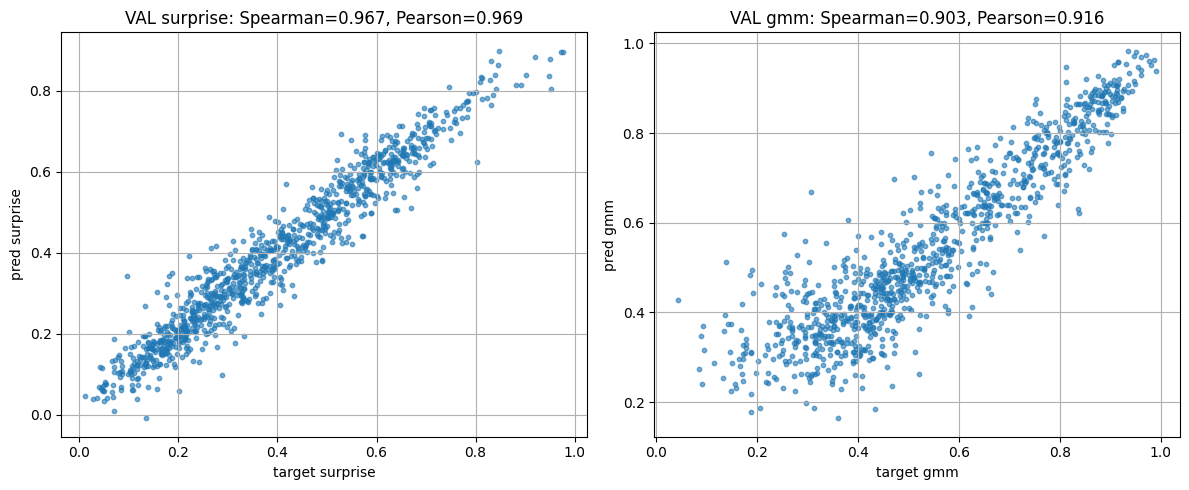

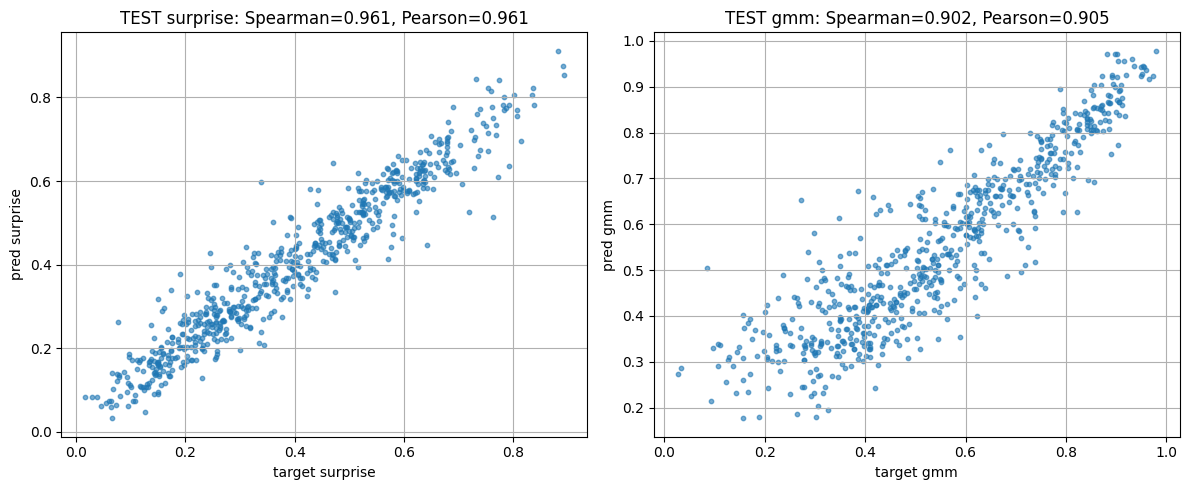

In [16]:
def scatter_pred_vs_target(out, title_prefix="VAL"):
    ps, ts = out["pred_surprise"], out["tgt_surprise"]
    pg, tg = out["pred_gmm"], out["tgt_gmm"]
    
    fig = plt.figure(figsize=(12,5))
    
    ax1 = plt.subplot(1,2,1)
    ax1.scatter(ts, ps, s=10, alpha=0.6)
    ax1.set_xlabel("target surprise")
    ax1.set_ylabel("pred surprise")
    ax1.set_title(f"{title_prefix} surprise: Spearman={spearman_corr(ps,ts):.3f}, Pearson={pearson_corr(ps,ts):.3f}")
    ax1.grid(True)
    
    ax2 = plt.subplot(1,2,2)
    ax2.scatter(tg, pg, s=10, alpha=0.6)
    ax2.set_xlabel("target gmm")
    ax2.set_ylabel("pred gmm")
    ax2.set_title(f"{title_prefix} gmm: Spearman={spearman_corr(pg,tg):.3f}, Pearson={pearson_corr(pg,tg):.3f}")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

scatter_pred_vs_target(val_out, "VAL")
scatter_pred_vs_target(test_out, "TEST")

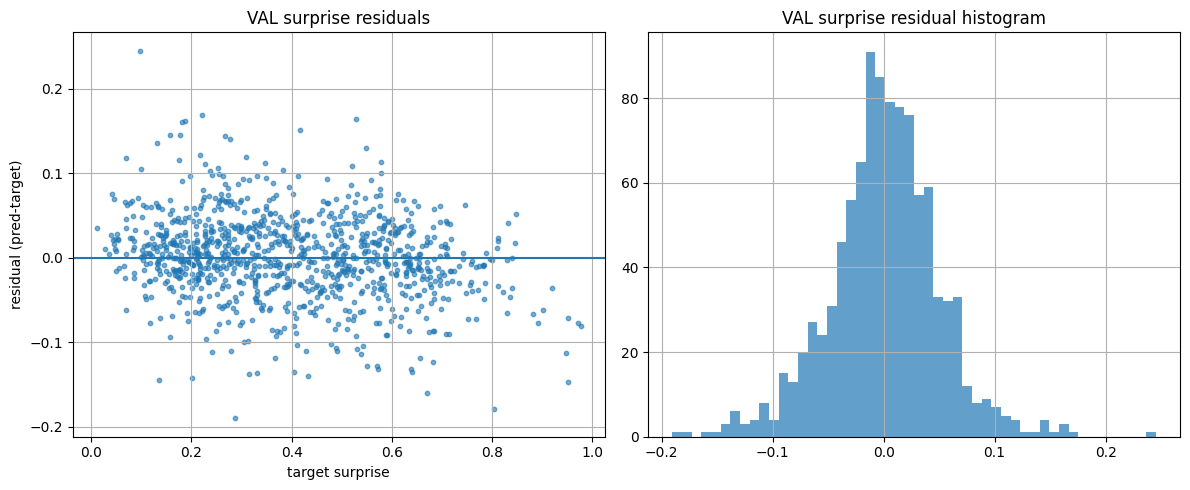

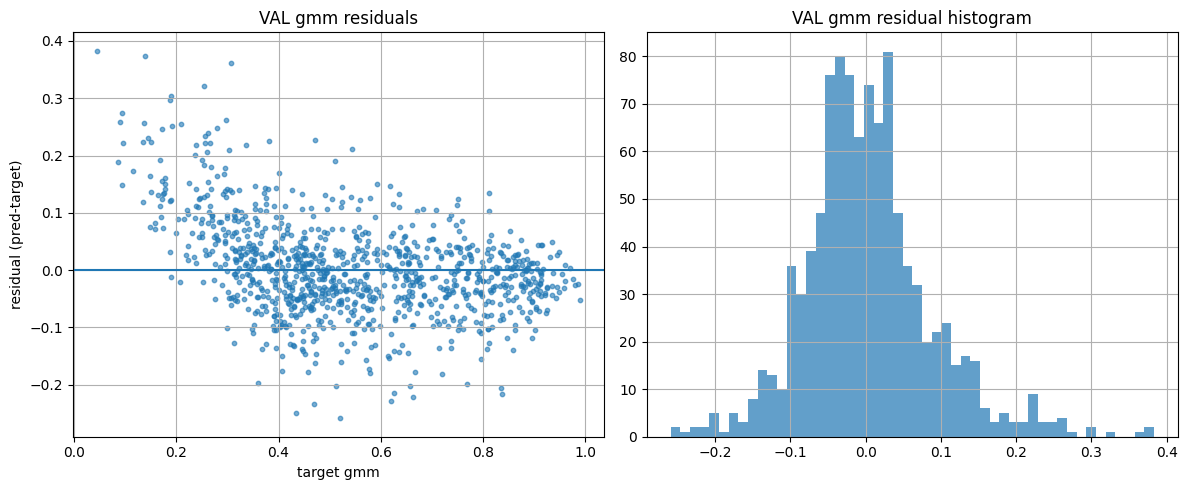

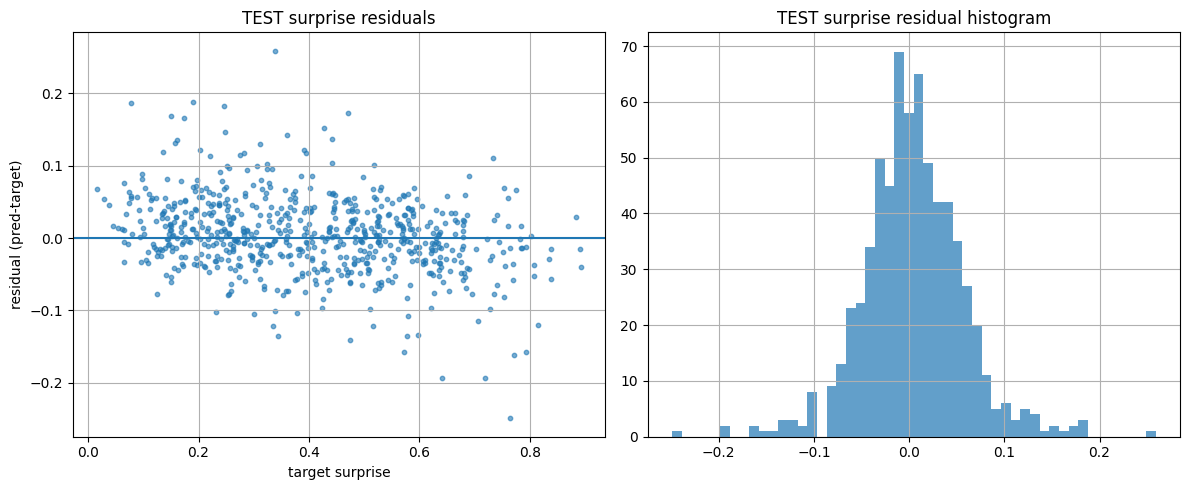

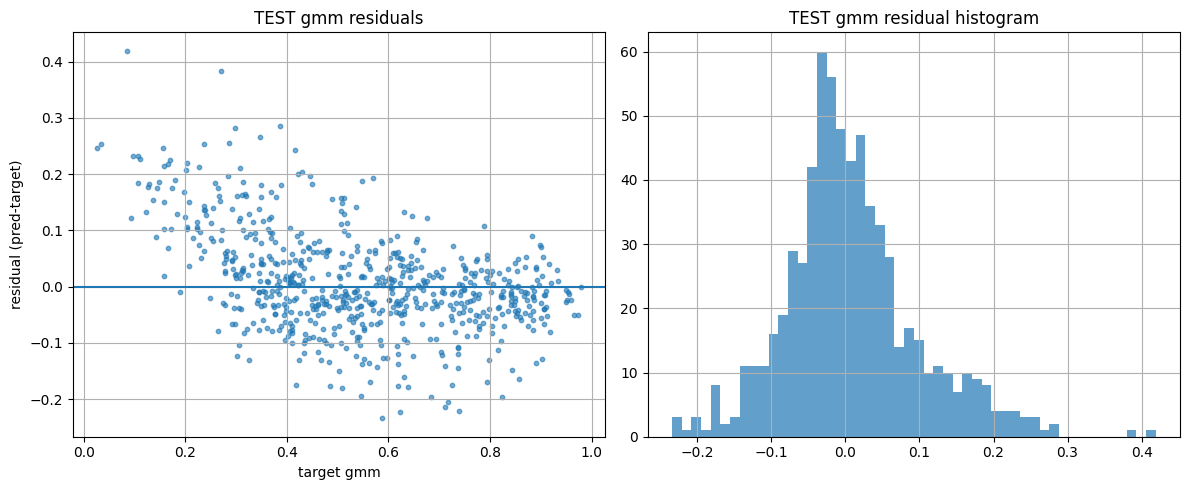

In [17]:
def residual_analysis(out, title_prefix="VAL"):
    ps, ts = out["pred_surprise"], out["tgt_surprise"]
    pg, tg = out["pred_gmm"], out["tgt_gmm"]
    rs = ps - ts
    rg = pg - tg
    
    fig = plt.figure(figsize=(12,5))
    
    ax1 = plt.subplot(1,2,1)
    ax1.scatter(ts, rs, s=10, alpha=0.6)
    ax1.axhline(0.0)
    ax1.set_xlabel("target surprise")
    ax1.set_ylabel("residual (pred-target)")
    ax1.set_title(f"{title_prefix} surprise residuals")
    ax1.grid(True)
    
    ax2 = plt.subplot(1,2,2)
    ax2.hist(rs, bins=50, alpha=0.7)
    ax2.set_title(f"{title_prefix} surprise residual histogram")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    fig = plt.figure(figsize=(12,5))
    
    ax1 = plt.subplot(1,2,1)
    ax1.scatter(tg, rg, s=10, alpha=0.6)
    ax1.axhline(0.0)
    ax1.set_xlabel("target gmm")
    ax1.set_ylabel("residual (pred-target)")
    ax1.set_title(f"{title_prefix} gmm residuals")
    ax1.grid(True)
    
    ax2 = plt.subplot(1,2,2)
    ax2.hist(rg, bins=50, alpha=0.7)
    ax2.set_title(f"{title_prefix} gmm residual histogram")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

residual_analysis(val_out, "VAL")
residual_analysis(test_out, "TEST")

In [18]:
def topk_overlap(pred, target, k):
    pred_idx = np.argsort(pred)[-k:]     # top-k
    tgt_idx  = np.argsort(target)[-k:]
    return len(set(pred_idx).intersection(set(tgt_idx))) / float(k)

def ranking_report(out, ks=(10, 25, 50, 100), title_prefix="VAL"):
    ps, ts = out["pred_surprise"], out["tgt_surprise"]
    pg, tg = out["pred_gmm"], out["tgt_gmm"]
    
    print(f"{title_prefix} ranking overlap (top-k)")
    for k in ks:
        if k >= len(ps): 
            continue
        ov_s = topk_overlap(ps, ts, k)
        ov_g = topk_overlap(pg, tg, k)
        print(f"  k={k:>4}: surprise overlap={ov_s:.3f} | gmm overlap={ov_g:.3f}")

ranking_report(val_out, title_prefix="VAL")
ranking_report(test_out, title_prefix="TEST")

VAL ranking overlap (top-k)
  k=  10: surprise overlap=0.700 | gmm overlap=0.500
  k=  25: surprise overlap=0.920 | gmm overlap=0.600
  k=  50: surprise overlap=0.820 | gmm overlap=0.680
  k= 100: surprise overlap=0.800 | gmm overlap=0.810
TEST ranking overlap (top-k)
  k=  10: surprise overlap=0.600 | gmm overlap=0.400
  k=  25: surprise overlap=0.720 | gmm overlap=0.640
  k=  50: surprise overlap=0.760 | gmm overlap=0.780
  k= 100: surprise overlap=0.830 | gmm overlap=0.860


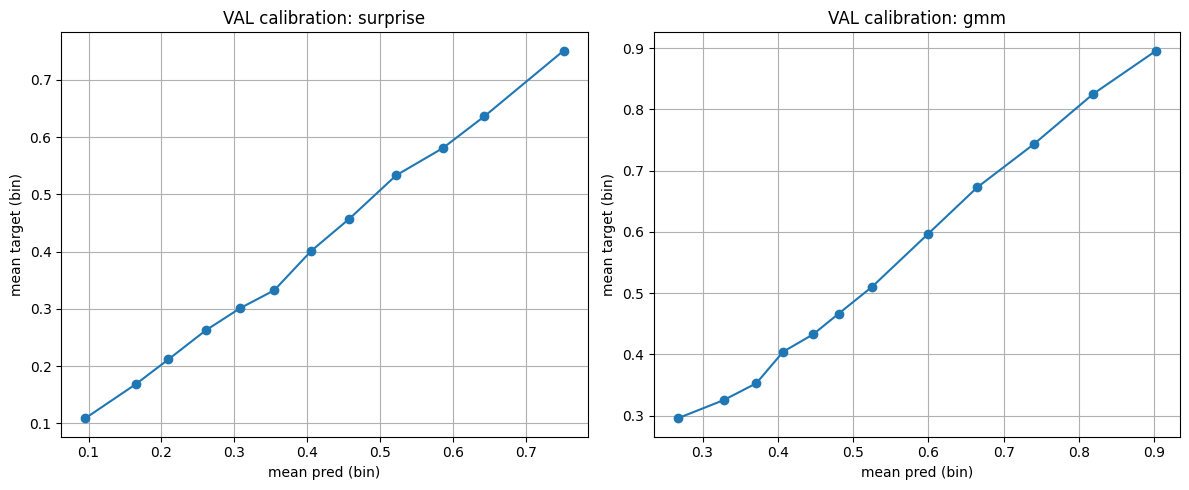

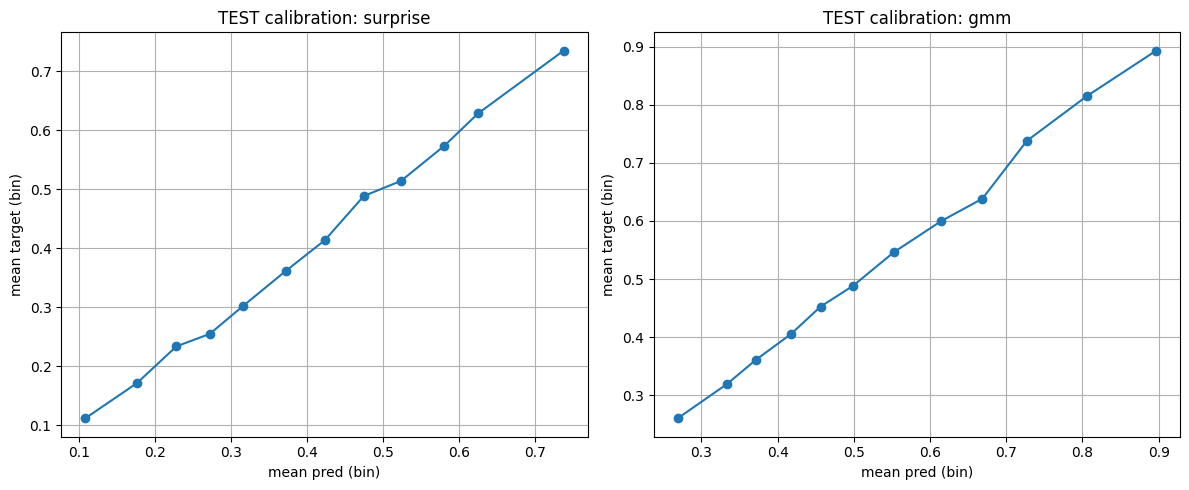

In [19]:
def calibration_bins(pred, target, n_bins=10):
    # bin by predicted quantiles
    q = np.quantile(pred, np.linspace(0, 1, n_bins+1))
    xs, ys, ns = [], [], []
    for i in range(n_bins):
        lo, hi = q[i], q[i+1]
        mask = (pred >= lo) & (pred <= hi if i == n_bins-1 else pred < hi)
        if mask.sum() == 0:
            continue
        xs.append(pred[mask].mean())
        ys.append(target[mask].mean())
        ns.append(mask.sum())
    return np.array(xs), np.array(ys), np.array(ns)

def plot_calibration(out, title_prefix="VAL", n_bins=10):
    ps, ts = out["pred_surprise"], out["tgt_surprise"]
    pg, tg = out["pred_gmm"], out["tgt_gmm"]
    
    xs, ys, ns = calibration_bins(ps, ts, n_bins=n_bins)
    xg, yg, ng = calibration_bins(pg, tg, n_bins=n_bins)
    
    fig = plt.figure(figsize=(12,5))
    
    ax1 = plt.subplot(1,2,1)
    ax1.plot(xs, ys, marker="o")
    ax1.set_xlabel("mean pred (bin)")
    ax1.set_ylabel("mean target (bin)")
    ax1.set_title(f"{title_prefix} calibration: surprise")
    ax1.grid(True)
    
    ax2 = plt.subplot(1,2,2)
    ax2.plot(xg, yg, marker="o")
    ax2.set_xlabel("mean pred (bin)")
    ax2.set_ylabel("mean target (bin)")
    ax2.set_title(f"{title_prefix} calibration: gmm")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_calibration(val_out, "VAL", n_bins=12)
plot_calibration(test_out, "TEST", n_bins=12)

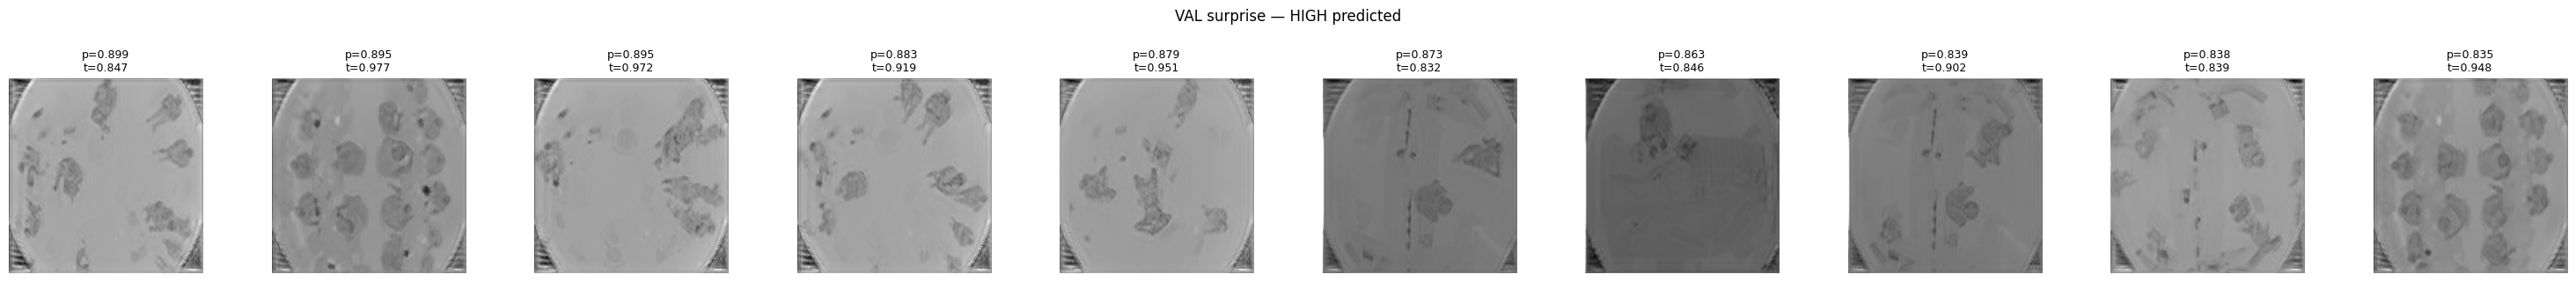

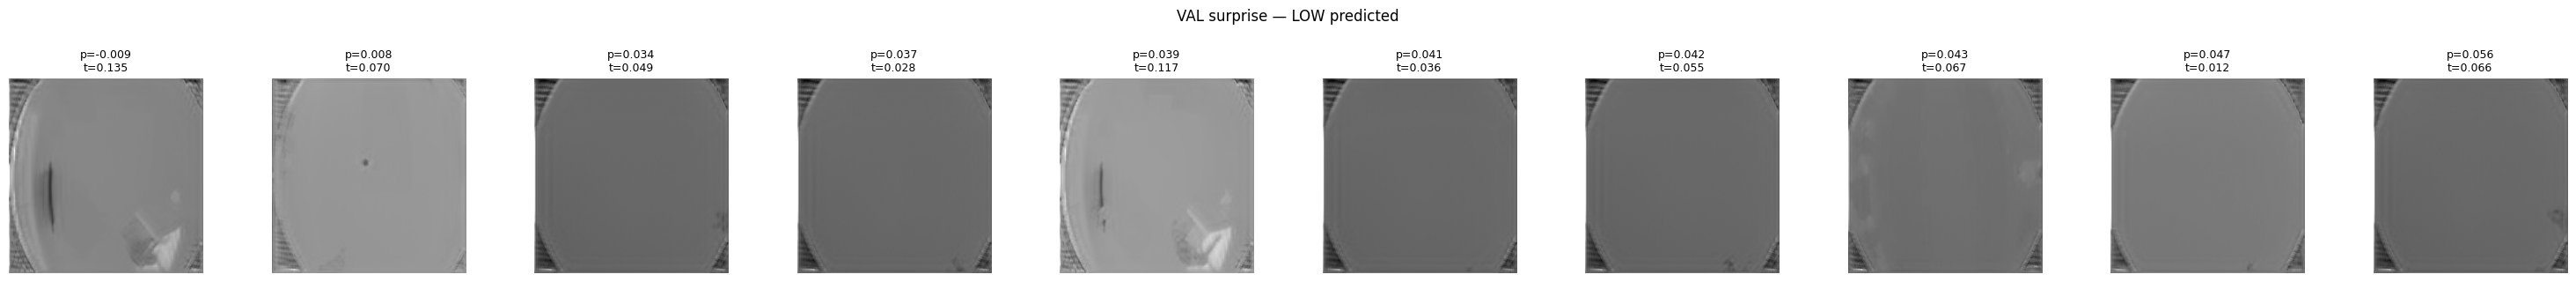

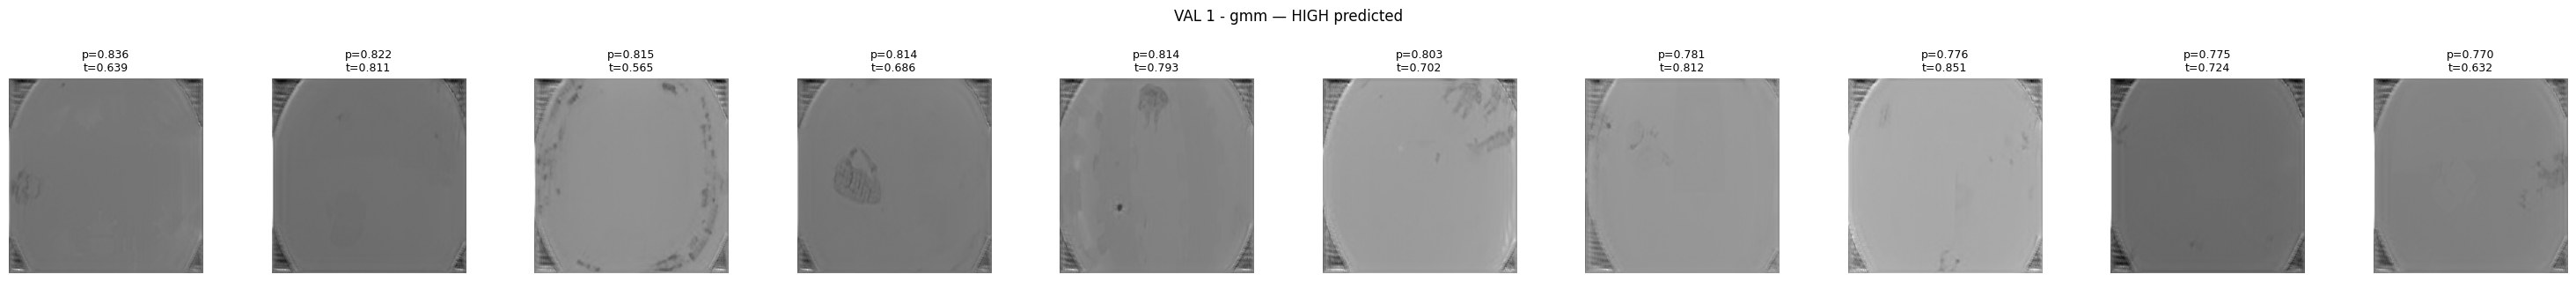

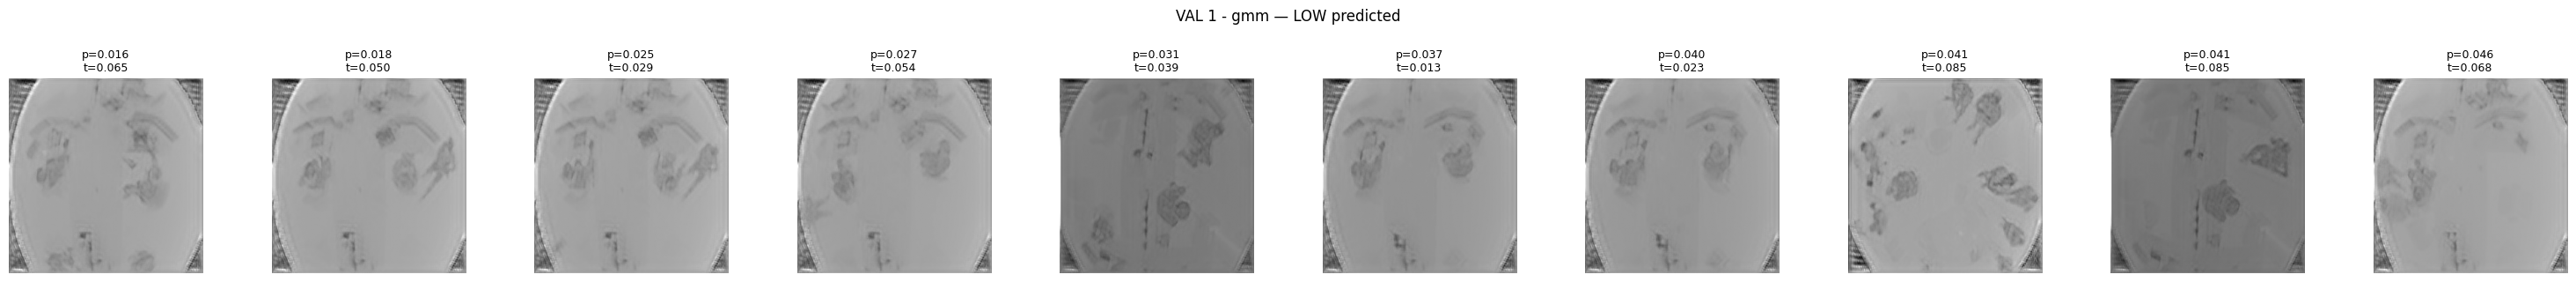

In [24]:
def decode_latent_to_img(model, z, device):
    """
    Returns a CPU numpy image in [0,1] for visualization.
    z: torch tensor (C,H,W) or (1,C,H,W)
    """
    model.eval()
    if z.ndim == 3:
        z = z.unsqueeze(0)
    z = z.to(device)

    with torch.no_grad():
        decoded = model._decode(z)
        if decoded.shape[1] != 1:
            decoded = decoded[:, :1]
        decoded = torch.nn.functional.interpolate(decoded, size=(256,256), mode="bilinear", align_corners=False)
        img = decoded[0,0]
        img = img - img.min()
        img = img / (img.max() - img.min() + 1e-8)
    return img.detach().cpu().numpy()

def show_extremes(out, ds, which="surprise", top_k=6, title_prefix="VAL"):
    if which == "surprise":
        pred = out["pred_surprise"]
        tgt  = out["tgt_surprise"]
    else:
        pred = 1 - out["pred_gmm"]
        tgt  = 1 - out["tgt_gmm"]
        
    idx_sorted = np.argsort(pred)
    low_idx = idx_sorted[:top_k]
    high_idx = idx_sorted[-top_k:][::-1]

    def plot_group(indices, group_name):
        n = len(indices)
        fig = plt.figure(figsize=(3*n, 3))
        for i, idx in enumerate(indices):
            stem = out["stems"][idx]
            # fetch item by stem: easiest by scanning ds.entries once into dict
            # build a mapping first time outside for speed
            item = stem_to_item[stem]
            img = decode_latent_to_img(model, item["z"], DEVICE)

            ax = plt.subplot(1, n, i+1)
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            ax.set_title(f"p={pred[idx]:.3f}\nt={tgt[idx]:.3f}", fontsize=9)
        plt.suptitle(f"{title_prefix} {which} — {group_name}", y=1.05)
        plt.tight_layout()
        plt.show()

    # Build a stem -> sample mapping from ds (contains z already)
    global stem_to_item
    stem_to_item = {}
    for i in range(len(ds)):
        it = ds[i]
        stem_to_item[it["stem"]] = it

    plot_group(high_idx, "HIGH predicted")
    plot_group(low_idx, "LOW predicted")

show_extremes(val_out, val_ds, which="surprise", top_k=10, title_prefix="VAL")
show_extremes(val_out, val_ds, which="1 - gmm", top_k=10, title_prefix="VAL")

In [21]:
def subset_metrics(out, mask, name="subset"):
    ps = out["pred_surprise"][mask]
    ts = out["tgt_surprise"][mask]
    pg = out["pred_gmm"][mask]
    tg = out["tgt_gmm"][mask]
    if len(ps) < 10:
        return {name: "too small"}
    return {
        f"{name}_n": int(mask.sum()),
        f"{name}_spearman_surprise": spearman_corr(ps, ts),
        f"{name}_spearman_gmm": spearman_corr(pg, tg),
        f"{name}_mae_surprise": float(np.mean(np.abs(ps-ts))),
        f"{name}_mae_gmm": float(np.mean(np.abs(pg-tg))),
    }

def confidence_subset(out, frac=0.2):
    """
    Example confidence: keep only samples in top frac of |pred - mean(pred)|.
    """
    ps = out["pred_surprise"]
    score = np.abs(ps - ps.mean())
    thresh = np.quantile(score, 1.0 - frac)
    return score >= thresh

mask_val = confidence_subset(val_out, frac=0.2)
print("VAL full:", val_metrics)
print("VAL subset:", subset_metrics(val_out, mask_val, name="conf20"))

mask_test = confidence_subset(test_out, frac=0.2)
print("\nTEST full:", test_metrics)
print("TEST subset:", subset_metrics(test_out, mask_test, name="conf20"))

print("\nRule of thumb for FM integration:")
print("- If Spearman on TEST is stable (e.g., >= 0.4–0.6) AND calibration-by-bins is monotonic,")
print("  it’s usually good enough as a *soft guidance* signal.")
print("- If Spearman collapses on TEST or calibration is non-monotonic,")
print("  consider: (a) using ranking-only objectives, (b) trusting only extremes, or (c) training longer / larger head.")

VAL full: {'spearman_surprise': 0.9671927807885349, 'pearson_surprise': 0.9685429930686951, 'mae_surprise': 0.03734917193651199, 'mse_surprise': 0.0024734479375183582, 'spearman_gmm': 0.9033922070530712, 'pearson_gmm': 0.9163167476654053, 'mae_gmm': 0.06253441423177719, 'mse_gmm': 0.007158779539167881}
VAL subset: {'conf20_n': 202, 'conf20_spearman_surprise': 0.933796364711098, 'conf20_spearman_gmm': 0.91745219665706, 'conf20_mae_surprise': 0.034754328429698944, 'conf20_mae_gmm': 0.06350815296173096}

TEST full: {'spearman_surprise': 0.9608101627259789, 'pearson_surprise': 0.9608761668205261, 'mae_surprise': 0.039652105420827866, 'mse_surprise': 0.002889391500502825, 'spearman_gmm': 0.9024055378523993, 'pearson_gmm': 0.9053757190704346, 'mae_gmm': 0.06671717762947083, 'mse_gmm': 0.008135724812746048}
TEST subset: {'conf20_n': 135, 'conf20_spearman_surprise': 0.930499463466979, 'conf20_spearman_gmm': 0.9397570968685982, 'conf20_mae_surprise': 0.03210461139678955, 'conf20_mae_gmm': 0.057